# Ejercicio de análisis de Serie Temporal: Air Passengers
        Number of air passengers per month
        Context
        Air Passengers per month. Workshop dataset

# Paso 1: Cargar librerías
    # Importamos las librerías necesarias para manipulación de datos, visualización, análisis estadístico y modelado.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error

In [4]:
# Librerías para auto_arima y LSTM
import pmdarima as pm
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense

# Paso 2: Cargar el dataset
        # Leemos el archivo CSV y renombramos las columnas para facilidad. Convertimos la columna 'Month' en índice de fecha.


In [ ]:
df = pd.read_csv('/kaggle/input/air-passengers/AirPassengers.csv')
#df = pd.read_csv(r'C:\americo\ia_dema\12_Machine Learning\04_Series_Temporales\AirPassengers.csv')
df.columns = ['Month', 'Passengers']
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

In [6]:
df.head()

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


# Paso 3: Visualizar la serie temporal
        # Mostramos la evolución mensual del número de pasajeros para detectar visualmente tendencias o estacionalidades.


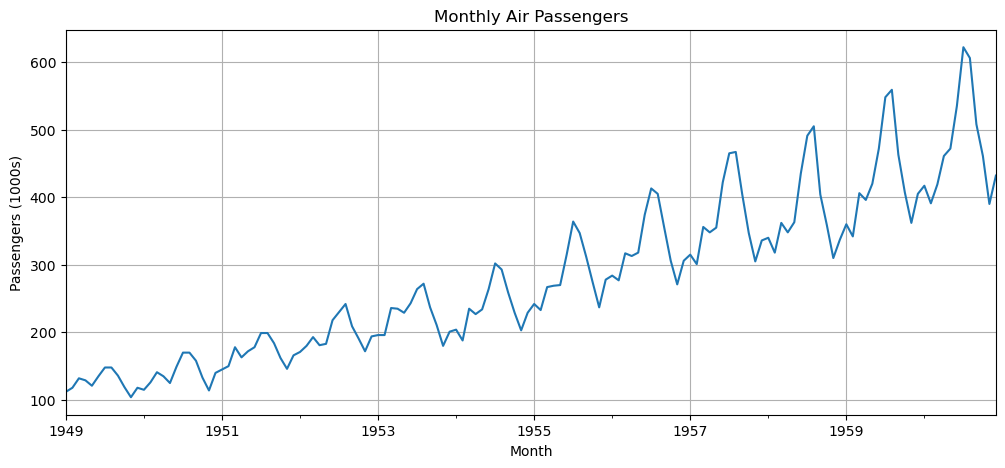

In [7]:
df['Passengers'].plot(figsize=(12, 5), title='Monthly Air Passengers')
plt.ylabel('Passengers (1000s)')
plt.grid()
plt.show()

# Paso 4: Descomposición de la serie temporal
        # Separar la serie en tendencia, estacionalidad y residuo. Nos ayuda a entender mejor su comportamiento.

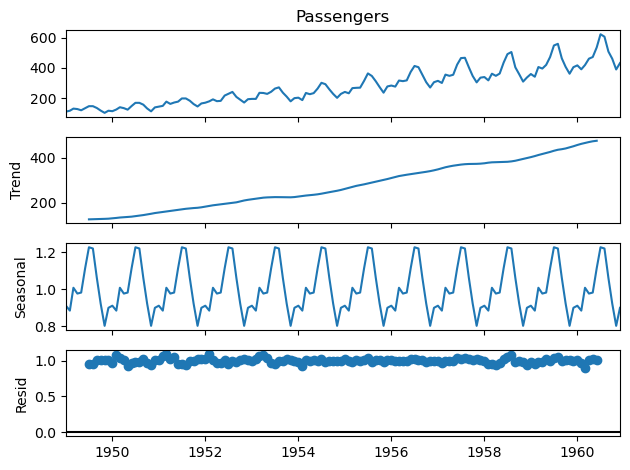

In [8]:
decomp = seasonal_decompose(df['Passengers'], model='multiplicative')
decomp.plot()
plt.show()

# Paso 5: Prueba de estacionariedad
        # Aplicamos la prueba de Dickey-Fuller para ver si la serie es estacionaria (es decir, si su media y varianza no cambian en el tiempo).


In [9]:
result_adf = adfuller(df['Passengers'])
print('ADF Statistic:', result_adf[0])
print('p-value:', result_adf[1])
# Si el p-valor > 0.05, la serie no es estacionaria y requerirá diferenciación.

ADF Statistic: 0.8153688792060482
p-value: 0.991880243437641


# Paso 6: Diferenciación si no es estacionaria
        # Calculamos la diferencia entre valores sucesivos para intentar estabilizar la serie.

In [10]:
df_diff = df['Passengers'].diff().dropna()

# Verificamos si la serie diferenciada es ahora estacionaria
        # Esta prueba asegura que una sola diferenciación es suficiente antes de seguir al modelado.

In [11]:
result_adf_diff = adfuller(df_diff)
print('ADF Statistic after differencing:', result_adf_diff[0])
print('p-value after differencing:', result_adf_diff[1])
# Si el p-valor < 0.05 ahora, entonces la serie ya es estacionaria y podemos continuar con ARIMA.

ADF Statistic after differencing: -2.8292668241699994
p-value after differencing: 0.0542132902838255


# Paso 7: ACF y PACF para elegir p y q
        # Usamos estas gráficas para determinar los parámetros del modelo ARIMA: p (autorregresivo) y q (promedios móviles).

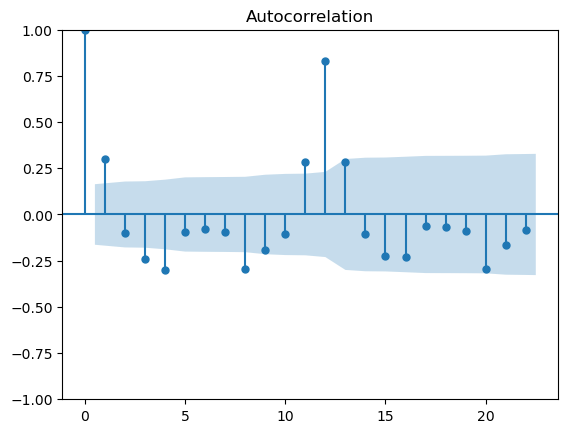

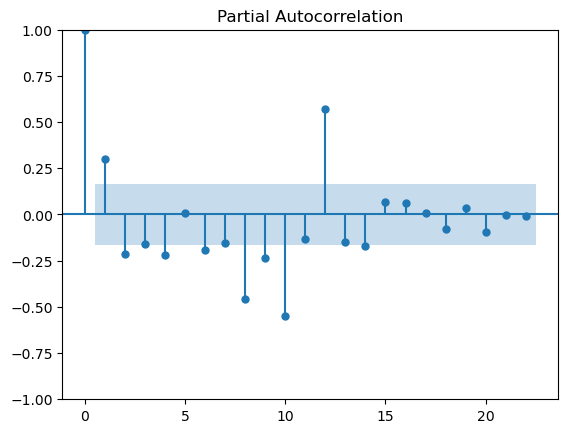

In [12]:
plot_acf(df_diff)
plt.show()
plot_pacf(df_diff)
plt.show()

# Paso 8: Ajuste del modelo ARIMA con auto_arima
        # auto_arima prueba múltiples combinaciones de parámetros y escoge la mejor según AIC.

In [13]:
model_auto = pm.auto_arima(df['Passengers'], seasonal=True, m=12, stepwise=True, trace=True)
print(model_auto.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=1020.048, Time=0.97 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1031.508, Time=0.04 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1020.393, Time=0.11 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=1021.003, Time=0.15 sec
 ARIMA(2,1,2)(0,1,1)[12]             : AIC=1019.935, Time=0.47 sec
 ARIMA(2,1,2)(0,1,0)[12]             : AIC=1019.290, Time=0.22 sec
 ARIMA(2,1,2)(1,1,0)[12]             : AIC=1019.546, Time=0.49 sec
 ARIMA(1,1,2)(0,1,0)[12]             : AIC=1024.160, Time=0.14 sec
 ARIMA(2,1,1)(0,1,0)[12]             : AIC=1017.847, Time=0.23 sec
 ARIMA(2,1,1)(1,1,0)[12]             : AIC=1017.914, Time=0.44 sec
 ARIMA(2,1,1)(0,1,1)[12]             : AIC=1018.359, Time=0.41 sec
 ARIMA(2,1,1)(1,1,1)[12]             : AIC=1018.248, Time=0.78 sec
 ARIMA(1,1,1)(0,1,0)[12]             : AIC=1022.393, Time=0.09 sec
 ARIMA(2,1,0)(0,1,0)[12]             : AIC=1022.393, Time=0.08 sec
 ARIMA(3,1,1)(0,1,0

# Paso 9: Predicciones con auto_arima

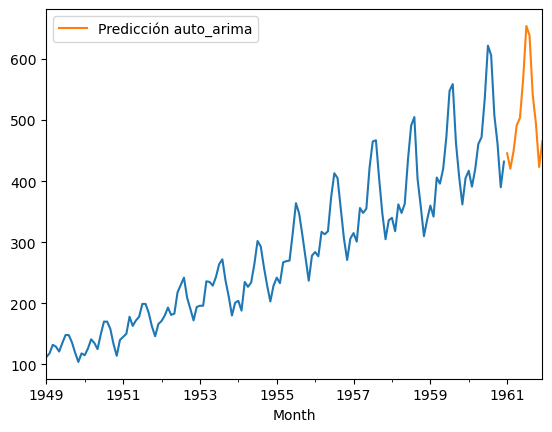

In [14]:
n_periods = 12
forecast_auto = model_auto.predict(n_periods=n_periods)
index_future = pd.date_range(df.index[-1] + pd.DateOffset(months=1), periods=n_periods, freq='MS')
forecast_series = pd.Series(forecast_auto, index=index_future)
df['Passengers'].plot(label='Real')
forecast_series.plot(label='Predicción auto_arima', legend=True)
plt.show()

# Paso 10: Evaluar el modelo ARIMA auto_arima
            # Calculamos el error de las predicciones del modelo auto_arima comparándolas con los últimos 12 datos reales.
            # Esto nos da una métrica objetiva de qué tan bien predice el modelo.

RMSE auto_arima: 31.71


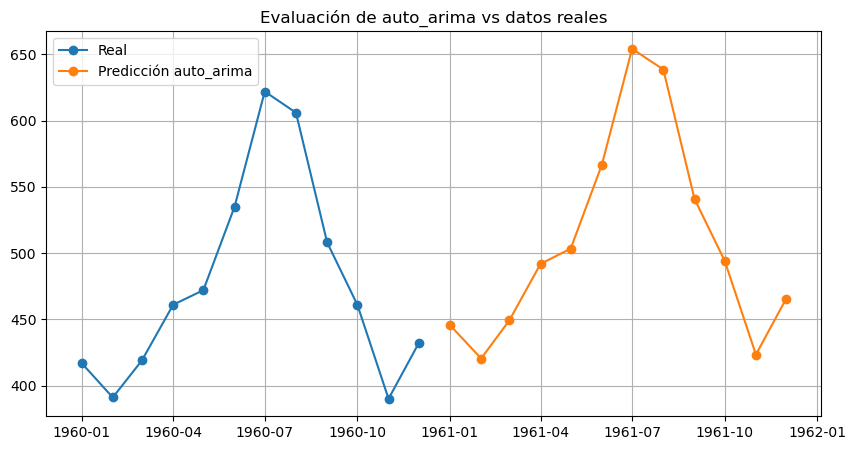

In [15]:
real_values = df['Passengers'][-12:].values
rmse_auto = np.sqrt(mean_squared_error(real_values, forecast_auto))
print(f'RMSE auto_arima: {rmse_auto:.2f}')

# Visualización comparativa específica de este período
plt.figure(figsize=(10,5))
plt.plot(df.index[-12:], real_values, label='Real', marker='o')
plt.plot(index_future, forecast_auto, label='Predicción auto_arima', marker='o')
plt.title('Evaluación de auto_arima vs datos reales')
plt.legend()
plt.grid()
plt.show()

# Paso 11: Preparar datos para LSTM
        # Normalizamos y reestructuramos la serie para que sea compatible con LSTM (input: [samples, time steps, features])

In [16]:
data = df['Passengers'].values.reshape(-1, 1)
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

X, y = [], []
for i in range(12, len(data_scaled)):
    X.append(data_scaled[i-12:i, 0])
    y.append(data_scaled[i, 0])
X, y = np.array(X), np.array(y)
X = X.reshape((X.shape[0], X.shape[1], 1))

# Paso 12: Modelo LSTM

In [17]:
model_lstm = Sequential()
model_lstm.add(LSTM(units=50, return_sequences=False, input_shape=(X.shape[1], 1)))
model_lstm.add(Dense(1))
model_lstm.compile(optimizer='adam', loss='mean_squared_error')
model_lstm.fit(X, y, epochs=50, batch_size=16)

c:\Users\Dell\Documents\Angel\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.1764
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0312
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0213
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0127
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0115
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0161
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0109
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0114
Epoch 9/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0108
Epoch 10/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0105
Epoch 11/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0093
Epoch 12/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0086
Epoch 13/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0082
Epoch 14/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0123
Epoch 15/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0095
Epoch 16/50
9/9 ━━━━━━━━━━━━━━━━━━━

# Paso 13: Predicción con LSTM

In [18]:
pred_lstm = model_lstm.predict(X)
pred_lstm = scaler.inverse_transform(pred_lstm.reshape(-1, 1))

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step


# Paso 14: Visualización resultados LSTM
        # Graficamos las predicciones del modelo LSTM frente a los datos reales para visualizar su rendimiento en el tiempo.

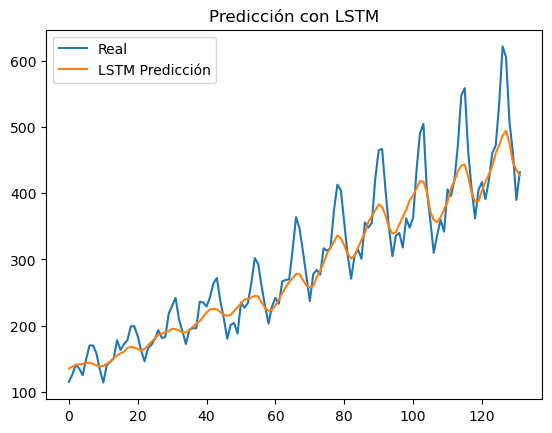

In [19]:
real = df['Passengers'].values[12:]
plt.plot(real, label='Real')
plt.plot(pred_lstm, label='LSTM Predicción')
plt.legend()
plt.title('Predicción con LSTM')
plt.show()

# Paso 15: Evaluar el modelo LSTM
        # Comparamos los valores predichos por el modelo LSTM con los reales (a partir del mes 13), y calculamos el RMSE.

In [20]:
rmse_lstm = np.sqrt(mean_squared_error(real, pred_lstm))
print(f'RMSE LSTM: {rmse_lstm:.2f}')

RMSE LSTM: 36.31


# Paso 16: Comparación final de rendimiento entre ARIMA y LSTM
        # Mostramos los dos errores para decidir qué modelo se ajusta mejor a los datos.

In [21]:
print("Comparativa de modelos:")
print(f"- RMSE auto_arima: {rmse_auto:.2f}")
print(f"- RMSE LSTM: {rmse_lstm:.2f}")

Comparativa de modelos:
- RMSE auto_arima: 31.71
- RMSE LSTM: 36.31


# Gráfico comparativo (últimos 12 meses disponibles del conjunto real)

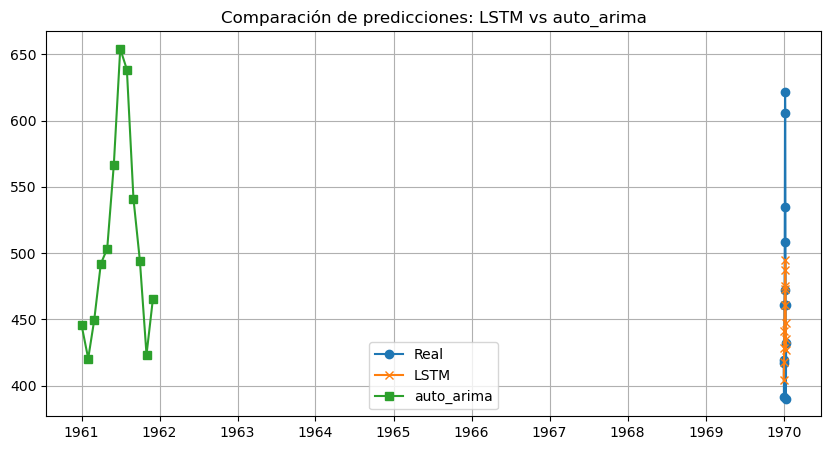

In [22]:
plt.figure(figsize=(10,5))
plt.plot(real[-12:], label='Real', marker='o')
plt.plot(pred_lstm[-12:], label='LSTM', marker='x')
plt.plot(forecast_auto, label='auto_arima', marker='s')
plt.title('Comparación de predicciones: LSTM vs auto_arima')
plt.legend()
plt.grid()
plt.show()